# CNN 混凝土裂缝识别：可对照的模型优化

整体结构：配置 → 数据与固定分组 → 模型工厂 → 训练及验证 → 最佳检查点 → 诊断与独立预测。每块均保留中文说明。

- 原模型 ConcreteCrackCNN 完整保留，约 1285 万参数；改进候选 ImprovedCrackCNN 用更小的特征分类层、BatchNorm 和 Dropout。
- 第 2 节选择模型；默认改进 CNN、翻转增强、学习率 0.0001、最多 30 轮。类别权重和原验证分组保持不变。
- SPLIT_SEED 固定划分，SEED 控制模型与训练随机性。重复不同随机种子时不要改变 SPLIT_SEED。
- 训练：顺序运行第 1–19 节。输出到新实验目录，历史模型不会被静默覆盖。
- 只预测：运行第 1、2、3、9、17、21 节，并将 CHECKPOINT_OVERRIDE 指向已有模型。
- 第 20 节最终测试和第 22 节小样本诊断默认关闭。测试集不用于挑选模型。
- 原翻转 CNN 验证 F1 约 0.523、BA 约 0.727，是待比较的历史基准；优化代码本身不等于精度已经提升。

本文件整理前的原件及执行输出已备份到 _backups。

## 1 导入依赖与定义类别名称

用途：导入后续代码需要的库，并固定类别顺序。

运行时机：每次重启内核后首先运行。输出：PyTorch 版本和 CUDA 是否可用。

In [1]:
# 1 导入依赖与定义类别名称
# 用途和运行条件见上方说明单元。

from collections import Counter
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

CLASS_NAMES = ('uncracked', 'cracked')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.11.0+cu128
CUDA available: True


## 2 统一实验配置

集中管理模型选择、增强开关、学习率、输出目录和两种随机种子。划分种子与训练种子已分开：重复不同初始化实验时只改 SEED，保持 SPLIT_SEED 不变。默认训练改进 CNN；选择 ConcreteCrackCNN 可复用原模型。已有模型的目录不会被训练单元静默覆盖。

In [2]:
# 2 实验配置：模型、数据划分和训练参数
PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'SDNET2018' / 'SDNET2018'

# 改模型时只修改这一项；原报告模型仍可选 ConcreteCrackCNN。
MODEL_NAME = 'ImprovedCrackCNN'
DROPOUT = 0.3
MODEL_KWARGS = {'dropout': DROPOUT} if MODEL_NAME == 'ImprovedCrackCNN' else {}
SPLIT_SEED = 42       # 固定数据划分，比较实验时不要修改
SEED = 42            # 模型初始化、训练打乱及增强的随机种子
USE_FLIPS = True
LEARNING_RATE = 0.0001
BATCH_SIZE = 32
EPOCHS = 30
PATIENCE = 5
NUM_WORKERS = 0
MAX_TRAIN_BATCHES = None
IMAGE_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

EXPERIMENT_NAME = 'improved_cnn_flip_lr1e4_seed42'
OUTPUT_DIR = PROJECT_ROOT / 'artifacts' / EXPERIMENT_NAME
# 只预测旧模型时可填 Path(r'完整模型路径')；None 表示使用本次实验最佳模型。
CHECKPOINT_OVERRIDE = None
RUN_TEST_EVALUATION = False
RUN_SMALL_SAMPLE_CHECK = False
assert MODEL_NAME in ('ConcreteCrackCNN', 'ImprovedCrackCNN')
assert EPOCHS > 0 and BATCH_SIZE > 0 and LEARNING_RATE > 0 and PATIENCE > 0
print('Dataset:', DATA_ROOT)
print('Experiment:', OUTPUT_DIR)
print('Model:', MODEL_NAME, MODEL_KWARGS)
print('Split seed / train seed:', SPLIT_SEED, SEED)

Dataset: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\SDNET2018\SDNET2018
Experiment: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42
Model: ImprovedCrackCNN {'dropout': 0.3}
Split seed / train seed: 42 42


## 3 固定随机种子并选择计算设备

用途：设置 Python、NumPy、PyTorch 的随机起点，自动选择 CUDA 或 CPU。固定种子有助于重复实验，但不能保证跨环境结果完全相同。

依赖：第 1、2 节。输出：设备和显卡名称。

In [3]:
# 3 固定随机种子并选择计算设备
# 用途和运行条件见上方说明单元。

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 4 定义图像预处理与标签规则

用途：训练图片随机水平/垂直翻转；验证、测试和预测只使用固定预处理。所有图片转为 224×224 的 RGB Tensor 并标准化。

C 开头的目录映射为裂缝 1，U 开头映射为无裂缝 0。此处只定义处理规则和 Dataset 类，还没有加载图片列表。

In [4]:
# 4 定义图像预处理与标签规则
# 用途和运行条件见上方说明单元。

fixed_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN,
        std=STD,
    ),
])

train_transform = transforms.Compose([
    *([transforms.RandomHorizontalFlip(p=0.5),
       transforms.RandomVerticalFlip(p=0.5)] if USE_FLIPS else []),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN,
        std=STD,
    ),
])

# 验证、测试和单张预测统一使用固定预处理
transform = fixed_transform


def semantic_label(folder_name):
    prefix = folder_name.strip().upper()[:1]
    if prefix == 'C':
        return 1  # cracked
    if prefix == 'U':
        return 0  # uncracked
    raise ValueError(f'不支持的类别目录：{folder_name}')


class CrackImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(str(root), transform=transform)
        remapped = [
            (path, semantic_label(Path(path).parent.name))
            for path, _ in self.samples
        ]
        self.samples = remapped
        self.imgs = remapped
        self.targets = [target for _, target in remapped]
        self.classes = list(CLASS_NAMES)
        self.class_to_idx = {'uncracked': 0, 'cracked': 1}

## 5 加载数据列表并检查类别数量

用途：分别创建训练增强版、训练固定版和测试版数据集，检查前两者图片顺序一致。

依赖：第 1–4 节及 DATA_ROOT 下的 train/test 目录。输出：两类图片数量；不会复制或移动原始图片。

In [5]:
# 5 加载数据列表并检查类别数量
# 用途和运行条件见上方说明单元。

assert (DATA_ROOT / 'train').is_dir(), f'找不到训练集：{DATA_ROOT / "train"}'
assert (DATA_ROOT / 'test').is_dir(), f'找不到测试集：{DATA_ROOT / "test"}'

train_full = CrackImageFolder(DATA_ROOT / 'train', transform=fixed_transform)
train_aug_full = CrackImageFolder(DATA_ROOT / 'train', transform=train_transform)
test_full = CrackImageFolder(DATA_ROOT / 'test', transform=fixed_transform)

assert [path for path, _ in train_full.samples] == [
    path for path, _ in train_aug_full.samples
], '固定预处理和增强预处理的图片顺序不一致'


def summarize(dataset):
    counts = Counter(dataset.targets)
    return {CLASS_NAMES[index]: counts[index] for index in range(2)}

print('Train:', summarize(train_full), 'total =', len(train_full))
print('Train augmented:', summarize(train_aug_full), 'total =', len(train_aug_full))
print('Test :', summarize(test_full), 'total =', len(test_full))
print('Positive class for Recall/F1: cracked(1)')

Train: {'uncracked': 11595, 'cracked': 2025} total = 13620
Train augmented: {'uncracked': 11595, 'cracked': 2025} total = 13620
Test : {'uncracked': 21726, 'cracked': 2608} total = 24334
Positive class for Recall/F1: cracked(1)


## 6 查看图片文件名

用途：打印每类前 10 个文件名，帮助检查命名方式。

例如 7001-1.jpg 的分组前缀是 7001。仅检查文件名不能证明标签内容正确；需要时再查看图片。依赖：第 5 节。

In [6]:
# 6 查看图片文件名
# 用途和运行条件见上方说明单元。

for label, name in enumerate(CLASS_NAMES):
    filenames = [
        Path(path).name
        for path, target in train_full.samples
        if target == label
    ]
    print(name, filenames[:10])

uncracked ['7001-1.jpg', '7001-10.jpg', '7001-100.jpg', '7001-101.jpg', '7001-102.jpg', '7001-103.jpg', '7001-104.jpg', '7001-105.jpg', '7001-106.jpg', '7001-107.jpg']
cracked ['7001-115.jpg', '7001-139.jpg', '7001-151.jpg', '7001-157.jpg', '7001-169.jpg', '7001-17.jpg', '7001-173.jpg', '7001-178.jpg', '7001-187.jpg', '7001-2.jpg']


## 7 固定照片分组，划分训练与验证数据

按文件名前缀分组，固定 SPLIT_SEED=42，保持原来 10,848 张训练、2,772 张验证的划分。改变模型初始化种子不会再改变验证集。该规则以文件名前缀代表来源分组；图片数量、路径或命名变化后需重新核对。

In [7]:
# 7 按文件名前缀划分训练集与验证集
# 用途和运行条件见上方说明单元。

# 1. 按文件名前缀分组
groups = {}

for index, (path, label) in enumerate(train_full.samples):
    group_id = Path(path).stem.split("-")[0]
    groups.setdefault(group_id, []).append(index)

# 2. 打乱组的顺序，抽取约 20% 的组作为验证集
group_ids = sorted(groups)
random.Random(SPLIT_SEED).shuffle(group_ids)

assert len(group_ids) >= 2, "分组数量不足，无法划分"

val_group_count = min(
    len(group_ids) - 1,
    max(1, round(len(group_ids) * 0.2))
)

val_groups = set(group_ids[:val_group_count])

# 3. 分别记录训练图片和验证图片的编号
train_indices = []
val_indices = []

for group_id, indices in groups.items():
    if group_id in val_groups:
        val_indices.extend(indices)
    else:
        train_indices.extend(indices)

# 4. 检查各部分的类别数量
def count_labels(indices):
    counts = Counter(train_full.targets[i] for i in indices)
    return {CLASS_NAMES[label]: counts[label] for label in range(2)}

print("总分组数：", len(groups))
print("验证集分组数：", len(val_groups))
print("训练集图片数：", len(train_indices), count_labels(train_indices))
print("验证集图片数：", len(val_indices), count_labels(val_indices))

assert set(train_indices).isdisjoint(val_indices)
assert len(train_indices) + len(val_indices) == len(train_full)

for indices in (train_indices, val_indices):
    assert {train_full.targets[i] for i in indices} == {0, 1}, \
        "某个集合缺少一个类别，需要调整分组划分"

总分组数： 54
验证集分组数： 11
训练集图片数： 10848 {'uncracked': 9250, 'cracked': 1598}
验证集图片数： 2772 {'uncracked': 2345, 'cracked': 427}


## 8 创建训练、验证、测试与诊断加载器

用途：训练加载器打乱图片并使用翻转增强；验证和测试加载器不打乱、使用固定预处理。

另建 train_eval_loader，专门在不随机翻转的条件下诊断训练集，便于和验证集比较。创建测试加载器不会执行测试。

In [8]:
# 8 创建训练、验证、测试与诊断加载器
# 用途和运行条件见上方说明单元。

# 训练使用翻转增强数据集，验证和测试使用固定预处理数据集
train_data = Subset(train_aug_full, train_indices)
val_data = Subset(train_full, val_indices)
test_data = test_full

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("参与训练：", len(train_loader.dataset))
print("用于验证：", len(val_loader.dataset))
print("用于测试：", len(test_loader.dataset))
print("训练翻转增强：", USE_FLIPS)
print("验证/测试预处理：固定 Resize + ToTensor + Normalize")

train_eval_loader = DataLoader(
    Subset(train_full, train_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

参与训练： 10848
用于验证： 2772
用于测试： 24334
训练翻转增强： True
验证/测试预处理：固定 Resize + ToTensor + Normalize


## 9 模型工厂：原始 CNN 与改进 CNN

原 CNN 保留，旧权重仍可加载。改进模型使用三级卷积和 BatchNorm，再将特征压缩为 4×4，避免原来 100352→128 的巨大全连接层；Dropout 只在训练时随机丢弃部分特征。输出仍为两类 logits，损失函数仍为加权交叉熵。该组合是新的架构候选，是否更准确需要验证实验，不能只凭参数更少判断。

In [9]:
# 9 定义 CNN 网络结构
# 用途和运行条件见上方说明单元。

class ConcreteCrackCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.relu3(self.fc1(x))
        return self.fc2(x)


class ImprovedCrackCNN(nn.Module):
    """较小的 CNN：三级卷积、批归一化、4×4 池化与 Dropout。"""
    def __init__(self, dropout=0.3):
        super().__init__()
        def block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(block(3, 16), block(16, 32), block(32, 64))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(name, kwargs=None):
    registry = {
        'ConcreteCrackCNN': ConcreteCrackCNN,
        'ImprovedCrackCNN': ImprovedCrackCNN,
    }
    if name not in registry:
        raise ValueError(f'未知模型：{name}')
    return registry[name](**(kwargs or {}))

## 10 训练与评估引擎

训练负责梯度更新，评估使用 inference_mode，不更新参数。损失按类别权重总和汇总；指标统一调用第 11 节 calculate_metrics，避免多套计算逻辑不一致。先运行第 11 节定义后再调用评估函数。

In [10]:
# 10 定义单轮训练与验证函数
# 用途和运行条件见上方说明单元。

def train_one_epoch(model, loader, criterion, optimizer, device, max_batches=None):
    model.train()
    weighted_loss_sum = 0.0
    weight_sum = 0.0
    for batch_index, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        batch_weights = (
            criterion.weight[labels]
            if criterion.weight is not None
            else torch.ones_like(labels, dtype=torch.float32)
        )
        weighted_loss_sum += loss.item() * batch_weights.sum().item()
        weight_sum += batch_weights.sum().item()
    if weight_sum == 0:
        raise ValueError("没有处理任何训练图片")
    return weighted_loss_sum / weight_sum


@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    weighted_loss_sum = 0.0
    weight_sum = 0.0
    targets, predictions = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        batch_weights = (
            criterion.weight[labels]
            if criterion.weight is not None
            else torch.ones_like(labels, dtype=torch.float32)
        )
        weighted_loss_sum += loss.item() * batch_weights.sum().item()
        weight_sum += batch_weights.sum().item()
        predicted = logits.argmax(dim=1)
        targets.extend(labels.cpu().tolist())
        predictions.extend(predicted.cpu().tolist())

    if weight_sum == 0:
        raise ValueError('评估数据集为空')
    return weighted_loss_sum / weight_sum, calculate_metrics(targets, predictions)

## 11 定义预测收集与分类指标函数

用途：收集整批预测，并计算以裂缝为正类的 Accuracy、Precision、Recall、F1、Specificity、BA。

这些是通用函数，供最终测试使用；运行本节本身不会访问测试集。

In [11]:
# 11 定义预测收集与分类指标函数
# 用途和运行条件见上方说明单元。

@torch.inference_mode()
def collect_predictions(model, loader, device):
    model.eval()
    targets, predictions = [], []
    for images, labels in loader:
        logits = model(images.to(device))
        predicted = logits.argmax(dim=1).cpu()
        targets.extend(labels.tolist())
        predictions.extend(predicted.tolist())
    return targets, predictions


def safe_div(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def calculate_metrics(targets, predictions):
    tp = sum(t == 1 and p == 1 for t, p in zip(targets, predictions))
    fp = sum(t == 0 and p == 1 for t, p in zip(targets, predictions))
    fn = sum(t == 1 and p == 0 for t, p in zip(targets, predictions))
    tn = sum(t == 0 and p == 0 for t, p in zip(targets, predictions))
    accuracy = safe_div(tp + tn, len(targets))
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    specificity = safe_div(tn, tn + fp)
    f1 = safe_div(2 * precision * recall, precision + recall)
    return {
        'accuracy': accuracy,
        'balanced_accuracy': (recall + specificity) / 2,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'true_positive': tp,
        'false_positive': fp,
        'false_negative': fn,
        'true_negative': tn,
        'total': len(targets),
    }

## 12 定义概率分布诊断函数

用途：统计预测裂缝概率的均值、标准差、分位数及两类真实标签下的平均概率，用于判断模型是否总预测同一类。

依赖：第 10 节。此处只定义函数；第 18 节才实际执行诊断。

In [12]:
# 12 定义概率分布诊断函数
# 用途和运行条件见上方说明单元。

@torch.inference_mode()
def collect_probability_diagnostics(model, loader, device):
    model.eval()
    targets, predictions, cracked_probabilities = [], [], []
    for images, labels in loader:
        probabilities = torch.softmax(model(images.to(device)), dim=1)
        predicted = probabilities.argmax(dim=1).cpu()
        targets.extend(labels.tolist())
        predictions.extend(predicted.tolist())
        cracked_probabilities.extend(probabilities[:, 1].cpu().tolist())
    return targets, predictions, np.array(cracked_probabilities)


def summarize_current_split(model, name, loader):
    loss, split_metrics = evaluate(model, loader, criterion, device)
    targets, predictions, cracked_probabilities = collect_probability_diagnostics(
        model, loader, device
    )
    summary = {
        'loss': loss,
        'metrics': split_metrics,
        'cracked_probability_mean': float(cracked_probabilities.mean()),
        'cracked_probability_std': float(cracked_probabilities.std()),
        'cracked_probability_quantiles': np.quantile(
            cracked_probabilities, [0, 0.25, 0.5, 0.75, 1]
        ).tolist(),
        'actual_uncracked_probability_mean': float(
            cracked_probabilities[np.array(targets) == 0].mean()
        ),
        'actual_cracked_probability_mean': float(
            cracked_probabilities[np.array(targets) == 1].mean()
        ),
    }
    print(f'[{name}] loss:', f"{loss:.6f}")
    print(f'[{name}] metrics:', split_metrics)
    print(f'[{name}] probability mean/std:', summary['cracked_probability_mean'], summary['cracked_probability_std'])
    print(f'[{name}] probability quantiles:', summary['cracked_probability_quantiles'])
    print(f'[{name}] actual-class probability means:', {
        'uncracked': summary['actual_uncracked_probability_mean'],
        'cracked': summary['actual_cracked_probability_mean'],
    })
    return summary

## 13 初始化选定模型、损失函数和优化器

从相同种子初始化第 2 节选择的网络。类别权重只根据训练子集计算；学习率仍为 0.0001，不同时新增学习率调度或采样策略。记录 run_config，供保存和加载使用。重复运行会重置模型；训练前需与 DataLoader 的初始化一并重新运行。

In [13]:
# 13 初始化新模型、类别权重和优化器
# 用途和运行条件见上方说明单元。

seed_everything(SEED)
model = build_model(MODEL_NAME, MODEL_KWARGS).to(device)
# 类别权重只根据实际参与训练的图片计算
train_labels = [train_full.targets[i] for i in train_indices]

class_counts = torch.bincount(
    torch.tensor(train_labels),
    minlength=2
).float()
class_weights = class_counts.sum() / (2 * class_counts)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))
print('Class counts:', class_counts.tolist())
print('Class weights:', class_weights.tolist())

run_config = {
    'experiment': EXPERIMENT_NAME,
    'model': MODEL_NAME, 'model_kwargs': dict(MODEL_KWARGS),
    'seed': SEED, 'split_seed': SPLIT_SEED,
    'learning_rate': LEARNING_RATE, 'batch_size': BATCH_SIZE,
    'epoch_limit': EPOCHS, 'early_stopping_patience': PATIENCE,
    'augmentation': ['horizontal_flip', 'vertical_flip'] if USE_FLIPS else [],
    'image_size': [IMAGE_SIZE, IMAGE_SIZE],
    'normalization': {'mean': MEAN, 'std': STD},
    'class_names': list(CLASS_NAMES), 'class_weights': class_weights.tolist(),
    'torch_version': str(torch.__version__), 'device': str(device),
    'parameter_count': sum(p.numel() for p in model.parameters()),
}

ImprovedCrackCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=F

## 14 执行训练与早停，每轮保存检查点

保持 30 轮上限、验证 F1 选择最佳模型和 patience=5。每轮保存最后模型及训练历史；最佳模型与最后模型都记录架构名称、构造参数和预处理信息。已存在的实验目录会报错，请设置新实验名，避免覆盖历史对照。检查点用于推理，尚未保存完整优化器和随机状态，不用于无缝断点续训。

In [14]:
# 14 开始训练、每轮验证并保存最佳模型
# 用途和运行条件见上方说明单元。

if (OUTPUT_DIR / 'model_last.pt').exists() or (OUTPUT_DIR / 'model_best.pt').exists():
    raise FileExistsError('实验目录已有模型，请在第 2 节设置新的 EXPERIMENT_NAME 后重启运行。')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'config.json').write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2), encoding='utf-8'
)
history = {
    'train_loss': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_specificity': [],
    'val_f1': [],
    'val_balanced_accuracy': [],
}
best_val_f1 = -1.0
best_epoch = 0
patience = PATIENCE
rounds_without_improvement = 0
started = time.perf_counter()

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device, MAX_TRAIN_BATCHES
    )
    val_loss, val_metrics = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_specificity'].append(val_metrics['specificity'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_balanced_accuracy'].append(val_metrics['balanced_accuracy'])

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'architecture': MODEL_NAME,
        'model_kwargs': dict(MODEL_KWARGS),
        'config': run_config,
        'class_names': list(CLASS_NAMES),
        'positive_class': 'cracked',
        'image_size': [224, 224],
        'normalization': {
            'mean': [0.485, 0.456, 0.406],
            'std': [0.229, 0.224, 0.225],
        },
        'loss': 'CrossEntropyLoss',
        'class_counts': class_counts.tolist(),
        'class_weights': class_weights.tolist(),
        'epoch': epoch + 1,
        'val_metrics': val_metrics,
    }
    torch.save(checkpoint, OUTPUT_DIR / 'model_last.pt')

    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_epoch = epoch + 1
        rounds_without_improvement = 0
        torch.save(checkpoint, OUTPUT_DIR / 'model_best.pt')
    else:
        rounds_without_improvement += 1

    print(
        f"Epoch {epoch + 1}/{EPOCHS}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Precision: {val_metrics['precision']:.4f}, "
        f"Val Recall: {val_metrics['recall']:.4f}, "
        f"Val F1: {val_metrics['f1']:.4f}, "
        f"Val BA: {val_metrics['balanced_accuracy']:.4f}"
    )

    (OUTPUT_DIR / 'history.json').write_text(
        json.dumps({'history': history, 'best_epoch': best_epoch,
                    'best_val_f1': best_val_f1, 'epochs_ran': len(history['train_loss']),
                    'elapsed_seconds': time.perf_counter() - started},
                   ensure_ascii=False, indent=2), encoding='utf-8'
    )

    if rounds_without_improvement >= patience:
        print(f'Early stopping after {patience} rounds without validation F1 improvement.')
        break

elapsed_seconds = time.perf_counter() - started
epochs_ran = len(history['train_loss'])
print(f'Training time: {elapsed_seconds:.2f} seconds')
print(f'Epochs ran: {epochs_ran}')
print(f'Best epoch by validation F1: {best_epoch}')
print(f'Best validation F1: {best_val_f1:.4f}')

Epoch 1/30, Train Loss: 0.6711, Val Loss: 0.6497, Val Precision: 0.3473, Val Recall: 0.4660, Val F1: 0.3980, Val BA: 0.6533
Epoch 2/30, Train Loss: 0.6537, Val Loss: 0.6290, Val Precision: 0.2557, Val Recall: 0.6604, Val F1: 0.3686, Val BA: 0.6552
Epoch 3/30, Train Loss: 0.6408, Val Loss: 0.6196, Val Precision: 0.3979, Val Recall: 0.4520, Val F1: 0.4232, Val BA: 0.6637
Epoch 4/30, Train Loss: 0.6321, Val Loss: 0.6169, Val Precision: 0.4416, Val Recall: 0.4075, Val F1: 0.4239, Val BA: 0.6568
Epoch 5/30, Train Loss: 0.6267, Val Loss: 0.6102, Val Precision: 0.4266, Val Recall: 0.4356, Val F1: 0.4311, Val BA: 0.6645
Epoch 6/30, Train Loss: 0.6168, Val Loss: 0.5858, Val Precision: 0.3916, Val Recall: 0.5457, Val F1: 0.4560, Val BA: 0.6956
Epoch 7/30, Train Loss: 0.6098, Val Loss: 0.5780, Val Precision: 0.2839, Val Recall: 0.7166, Val F1: 0.4066, Val BA: 0.6937
Epoch 8/30, Train Loss: 0.6030, Val Loss: 0.5881, Val Precision: 0.4428, Val Recall: 0.4895, Val F1: 0.4650, Val BA: 0.6887
Epoch 9/

## 15 保存配置、划分名单和训练历史

用途：保存 config.json、split.json、history.json 和 metrics.json。metrics.json 汇总的是最佳验证结果，不是测试成绩。

依赖：第 14 节训练完成。本节不重复保存模型参数，避免加载最佳模型后误把它覆盖为“最后模型”。split.json 同时保留分组名单和图片索引。

In [15]:
# 15 保存配置、划分名单和训练历史
# 用途和运行条件见上方说明单元。

best_index = best_epoch - 1
best_validation_metrics = {
    'precision': history['val_precision'][best_index],
    'recall': history['val_recall'][best_index],
    'specificity': history['val_specificity'][best_index],
    'f1': history['val_f1'][best_index],
    'balanced_accuracy': history['val_balanced_accuracy'][best_index],
}

epochs_ran = len(history['train_loss'])
# 两份模型已由训练循环保存；此处仅保存实验记录。


config = {**run_config, 'epochs_ran': epochs_ran}
(OUTPUT_DIR / 'config.json').write_text(
    json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8'
)

split = {
    'seed': SPLIT_SEED,
    'train_indices': train_indices,
    'validation_indices': val_indices,
    'validation_groups': sorted(val_groups),
    'training_groups': sorted(set(groups) - val_groups),
    'train_files': [str(Path(train_full.samples[i][0]).relative_to(DATA_ROOT)) for i in train_indices],
    'validation_files': [str(Path(train_full.samples[i][0]).relative_to(DATA_ROOT)) for i in val_indices],
    'train_count': len(train_indices),
    'validation_count': len(val_indices),
    'test_count': len(test_data),
    'train_labels': count_labels(train_indices),
    'validation_labels': count_labels(val_indices),
    'test_labels': summarize(test_full),
}
(OUTPUT_DIR / 'split.json').write_text(
    json.dumps(split, ensure_ascii=False, indent=2), encoding='utf-8'
)

(OUTPUT_DIR / 'history.json').write_text(
    json.dumps({
        'history': history,
        'best_epoch': best_epoch,
        'best_val_f1': best_val_f1,
        'epochs_ran': epochs_ran,
        'elapsed_seconds': elapsed_seconds,
    }, ensure_ascii=False, indent=2), encoding='utf-8'
)

metrics_summary = {
    'experiment': EXPERIMENT_NAME,
    'best_epoch': best_epoch,
    'best_validation_metrics': best_validation_metrics,
    'epochs_ran': epochs_ran,
    'train_count': len(train_indices),
    'validation_count': len(val_indices),
    'test_count': len(test_data),
    'device': str(device),
}
(OUTPUT_DIR / 'metrics.json').write_text(
    json.dumps(metrics_summary, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Saved:', OUTPUT_DIR / 'model_best.pt')
print('Saved:', OUTPUT_DIR / 'model_last.pt')
print('Saved:', OUTPUT_DIR / 'config.json')
print('Saved:', OUTPUT_DIR / 'split.json')
print('Saved:', OUTPUT_DIR / 'history.json')
print('Saved:', OUTPUT_DIR / 'metrics.json')

Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\model_best.pt
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\model_last.pt
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\config.json
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\split.json
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\history.json
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\metrics.json


## 16 绘制训练与验证损失曲线

用途：同时观察训练损失和验证损失随轮次的变化，辅助判断停滞或过拟合。训练损失来自增强图片，验证损失来自固定图片，不宜仅凭两条曲线的高低下结论。

依赖：训练后的 history。输出：learning_curves.png。

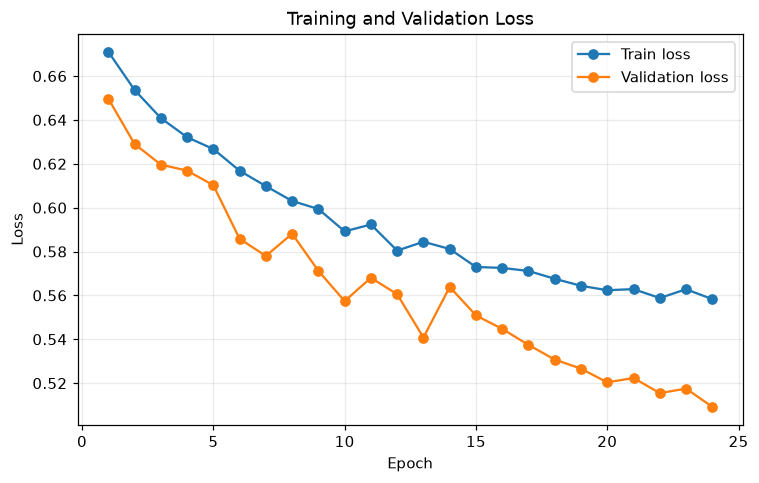

In [16]:
# 16 绘制训练与验证损失曲线
# 用途和运行条件见上方说明单元。

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], marker='o', label='Train loss')
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=160)
plt.show()

## 17 自动加载原模型或改进模型

读取检查点中的 architecture 和 model_kwargs 自动创建网络，严格加载权重；旧版 ConcreteCrackCNN 权重也兼容。预测预处理从检查点恢复，不依赖当前训练配置。只预测时运行第 1、2、3、9、17、21 节，在第 2 节用 CHECKPOINT_OVERRIDE 指向已有模型。

In [17]:
# 17 根据检查点自动构造模型与预测预处理
CHECKPOINT_PATH = Path(CHECKPOINT_OVERRIDE) if CHECKPOINT_OVERRIDE else OUTPUT_DIR / 'model_best.pt'
assert CHECKPOINT_PATH.is_file(), f'找不到模型：{CHECKPOINT_PATH}'
best_checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
assert best_checkpoint['class_names'] == list(CLASS_NAMES), '模型类别顺序不匹配'
inference_model = build_model(
    best_checkpoint['architecture'], best_checkpoint.get('model_kwargs', {})
).to(device)
inference_model.load_state_dict(best_checkpoint['model_state_dict'])
inference_model.eval()
normalization = best_checkpoint['normalization']
inference_transform = transforms.Compose([
    transforms.Resize(tuple(best_checkpoint['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalization['mean'], std=normalization['std']),
])
print('Loaded:', CHECKPOINT_PATH)
print('Architecture:', best_checkpoint['architecture'])
print('Best epoch:', best_checkpoint.get('epoch', '未记录'))

Loaded: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\model_best.pt
Architecture: ImprovedCrackCNN
Best epoch: 19


## 18 诊断最佳模型的训练集与验证集表现

用途：在固定预处理下比较训练集与验证集，查看分类指标和概率分布。

依赖：第 8、10、12、13、17 节。只做诊断，不更新参数。输出 diagnostics.json；不使用测试集选择方案。

In [18]:
# 18 诊断最佳模型的训练集与验证集表现
# 用途和运行条件见上方说明单元。

diagnostics = {
    'best_epoch': best_checkpoint.get('epoch'),
    'train': summarize_current_split(inference_model, 'train', train_eval_loader),
    'validation': summarize_current_split(inference_model, 'validation', val_loader),
}
(OUTPUT_DIR / 'diagnostics.json').write_text(
    json.dumps(diagnostics, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('Saved:', OUTPUT_DIR / 'diagnostics.json')

[train] loss: 0.559488
[train] metrics: {'accuracy': 0.8530604719764012, 'balanced_accuracy': 0.6969323816933329, 'precision': 0.5013192612137203, 'recall': 0.4755944931163955, 'specificity': 0.9182702702702703, 'f1': 0.48811817597944757, 'true_positive': 760, 'false_positive': 756, 'false_negative': 838, 'true_negative': 8494, 'total': 10848}
[train] probability mean/std: 0.32811535172982387 0.1892238912101513
[train] probability quantiles: [3.491050781789795e-10, 0.20507025346159935, 0.29469895362854004, 0.4123145788908005, 0.9993870258331299]
[train] actual-class probability means: {'uncracked': 0.29222289662322826, 'cracked': 0.5358783115145607}
[validation] loss: 0.526605
[validation] metrics: {'accuracy': 0.8603896103896104, 'balanced_accuracy': 0.7335978188681883, 'precision': 0.5465116279069767, 'recall': 0.550351288056206, 'specificity': 0.9168443496801706, 'f1': 0.5484247374562427, 'true_positive': 235, 'false_positive': 195, 'false_negative': 192, 'true_negative': 2150, 'tot

## 19 查看验证集误报与漏检图片

用途：各展示最多 12 张误报和漏检图片，帮助发现阴影、纹理或细小裂缝等误判模式。

依赖：第 8、12、17 节。输出 validation_misclassified.png 和 misclassified_examples.json。示例按当前顺序取前几张，不代表全部错误的分布。

False positives: 195
False negatives: 192
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\validation_misclassified.png
Saved: C:\Users\72758\Desktop\科研\output\cnn_crack_reproduction\artifacts\improved_cnn_flip_lr1e4_seed42\misclassified_examples.json


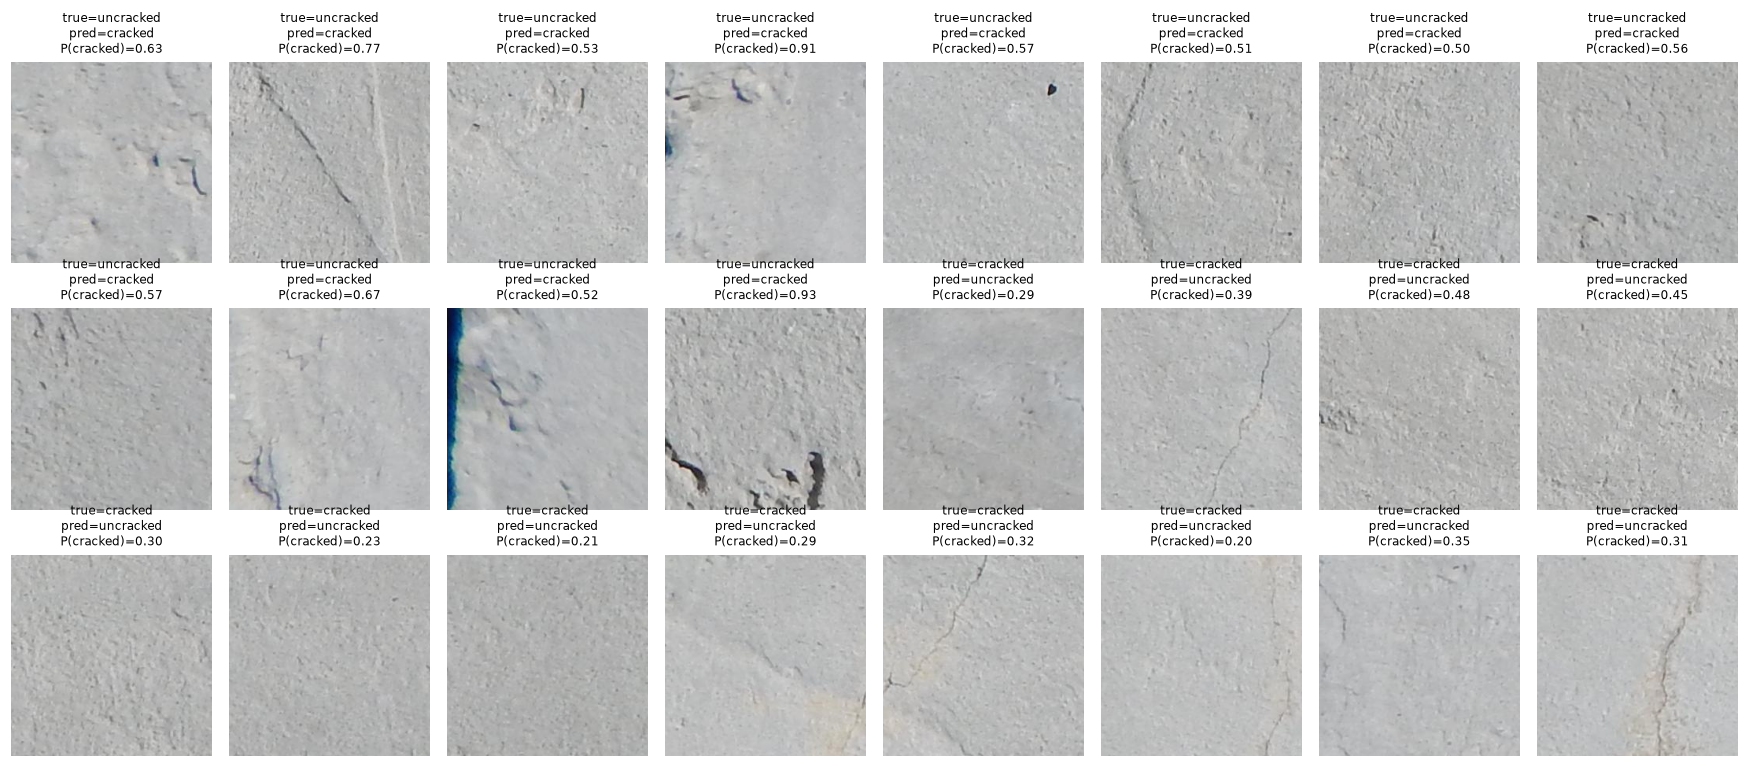

In [19]:
# 19 查看验证集误报与漏检图片
# 用途和运行条件见上方说明单元。

validation_targets, validation_predictions, validation_probabilities = (
    collect_probability_diagnostics(inference_model, val_loader, device)
)
false_positive_indices = [
    position
    for position, (target, prediction) in enumerate(
        zip(validation_targets, validation_predictions)
    )
    if target == 0 and prediction == 1
]
false_negative_indices = [
    position
    for position, (target, prediction) in enumerate(
        zip(validation_targets, validation_predictions)
    )
    if target == 1 and prediction == 0
]

error_positions = false_positive_indices[:12] + false_negative_indices[:12]
figure, axes = plt.subplots(3, 8, figsize=(16, 7))
for axis in axes.flat:
    axis.axis('off')
for axis, position in zip(axes.flat, error_positions):
    dataset_index = val_indices[position]
    image_path, target = train_full.samples[dataset_index]
    with Image.open(image_path) as image:
        axis.imshow(image.convert('RGB'))
    predicted_name = CLASS_NAMES[validation_predictions[position]]
    target_name = CLASS_NAMES[target]
    probability = validation_probabilities[position]
    axis.set_title(
        f'true={target_name}\npred={predicted_name}\nP(cracked)={probability:.2f}',
        fontsize=8,
    )

figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'validation_misclassified.png', dpi=160)
plt.show()

misclassified_summary = {
    'false_positive_count': len(false_positive_indices),
    'false_negative_count': len(false_negative_indices),
    'false_positive_examples': [
        train_full.samples[val_indices[position]][0]
        for position in false_positive_indices[:12]
    ],
    'false_negative_examples': [
        train_full.samples[val_indices[position]][0]
        for position in false_negative_indices[:12]
    ],
}
(OUTPUT_DIR / 'misclassified_examples.json').write_text(
    json.dumps(misclassified_summary, ensure_ascii=False, indent=2),
    encoding='utf-8',
)
print('False positives:', len(false_positive_indices))
print('False negatives:', len(false_negative_indices))
print('Saved:', OUTPUT_DIR / 'validation_misclassified.png')
print('Saved:', OUTPUT_DIR / 'misclassified_examples.json')

## 20 最终测试集评估（可选）

用途：方案确定后，评估最佳模型在测试集上的表现。默认 RUN_TEST_EVALUATION=False，整本运行时会跳过。

启用后依赖第 8、11、17 节。输出 test_metrics.json；不要反复根据测试成绩选择权重、模型或阈值。

In [20]:
# 20 最终测试集评估（可选）
# 用途和运行条件见上方说明单元。

if RUN_TEST_EVALUATION:
    targets, predictions = collect_predictions(inference_model, test_loader, device)
    test_metrics = calculate_metrics(targets, predictions)
    for name, value in test_metrics.items():
        print(f'{name}: {value:.4f}' if isinstance(value, float) else f'{name}: {value}')
    (OUTPUT_DIR / 'test_metrics.json').write_text(
        json.dumps(test_metrics, ensure_ascii=False, indent=2), encoding='utf-8'
    )
else:
    print("已跳过最终测试；方案确定后将 RUN_TEST_EVALUATION 改为 True。")

已跳过最终测试；方案确定后将 RUN_TEST_EVALUATION 改为 True。


## 21 独立预测自己的图片

只需导入、配置、设备、模型定义和加载模型即可预测，不依赖数据集或训练单元。修改 sample_path；使用模型文件记录的固定预处理。输出整张图片的分类及两类分数，不定位裂缝，不把模型分数视为可靠性保证。

Image: C:\Users\72758\Desktop\科研\download.jpg
Prediction: cracked
P(uncracked): 0.076354
P(cracked): 0.923646


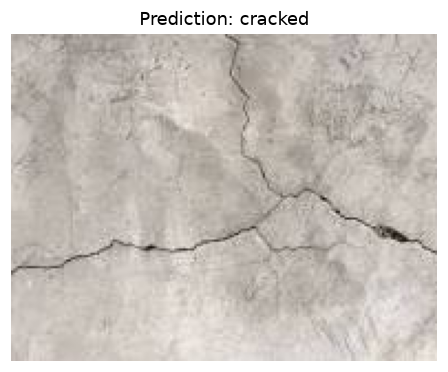

In [21]:
# 21 使用最佳模型识别自己的图片
# 用途和运行条件见上方说明单元。

sample_path = r"C:\Users\72758\Desktop\科研\download.jpg"
with Image.open(sample_path) as image:
    rgb_image = image.convert('RGB')
    input_tensor = inference_transform(rgb_image).unsqueeze(0).to(device)

inference_model.eval()
with torch.inference_mode():
    probabilities = torch.softmax(inference_model(input_tensor), dim=1)[0].cpu().numpy()

predicted_index = int(probabilities.argmax())
print('Image:', sample_path)
print('Prediction:', CLASS_NAMES[predicted_index])
print(f'P(uncracked): {probabilities[0]:.6f}')
print(f'P(cracked): {probabilities[1]:.6f}')

plt.figure(figsize=(5, 5))
plt.imshow(rgb_image)
plt.title(f'Prediction: {CLASS_NAMES[predicted_index]}')
plt.axis('off')
plt.show()

## 22 固定小样本学习能力检查（可选）

沿用各 16 张两类图片，检查当前选定模型是否能够学习。默认跳过；输出小样本诊断，不覆盖正式模型。小样本满分不能证明模型的泛化性能。

In [22]:
# 22 固定 32 张图片的学习能力检查（可选）
# 用途和运行条件见上方说明单元。

if RUN_SMALL_SAMPLE_CHECK:
    label_indices = {
        label: [index for index in train_indices if train_full.targets[index] == label]
        for label in range(2)
    }
    rng = random.Random(SEED)
    fixed_indices = []
    for label in range(2):
        selected = label_indices[label].copy()
        rng.shuffle(selected)
        fixed_indices.extend(selected[:16])
    rng.shuffle(fixed_indices)
    
    fixed_data = Subset(train_full, fixed_indices)
    fixed_loader = DataLoader(
        fixed_data,
        batch_size=32,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    print('Fixed diagnostic labels:', Counter(train_full.targets[index] for index in fixed_indices))
    print('Fixed diagnostic paths:')
    for index in fixed_indices:
        print(CLASS_NAMES[train_full.targets[index]], train_full.samples[index][0])
    
    figure, axes = plt.subplots(4, 8, figsize=(16, 8))
    for axis, index in zip(axes.flat, fixed_indices):
        image_path, label = train_full.samples[index]
        with Image.open(image_path) as image:
            axis.imshow(image.convert('RGB'))
        axis.set_title(CLASS_NAMES[label])
        axis.axis('off')
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / 'fixed_32_samples.png', dpi=160)
    plt.show()
    
    small_sample_results = []
    for repetition in range(3):
        seed_everything(SEED + repetition)
        small_model = build_model(MODEL_NAME, MODEL_KWARGS).to(device)
        small_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        small_optimizer = optim.Adam(small_model.parameters(), lr=LEARNING_RATE)
        for _ in range(50):
            train_one_epoch(
                small_model,
                fixed_loader,
                small_criterion,
                small_optimizer,
                device,
            )
        small_loss, small_metrics = evaluate(
            small_model,
            fixed_loader,
            small_criterion,
            device,
        )
        result = {
            'repetition': repetition + 1,
            'loss': small_loss,
            **small_metrics,
        }
        small_sample_results.append(result)
        print(f'Fixed 32 samples repetition {repetition + 1}:', result)
    
    (OUTPUT_DIR / 'small_sample_diagnostics.json').write_text(
        json.dumps({'small_sample_results': small_sample_results}, indent=2),
        encoding='utf-8',
    )
    print('Saved:', OUTPUT_DIR / 'fixed_32_samples.png')
    print('Saved:', OUTPUT_DIR / 'small_sample_diagnostics.json')
else:
    print("已跳过固定 32 张图片检查；需要排错时再启用 RUN_SMALL_SAMPLE_CHECK。")

已跳过固定 32 张图片检查；需要排错时再启用 RUN_SMALL_SAMPLE_CHECK。


## 实验比较与应用边界

比较不同模型时，固定数据划分、增强、学习率和评价方法，查看验证 Precision、Recall、F1 和 BA。改进网络同时改变了特征层、池化和正则化，若有提升，只能归因于这一组合；确认单独组件的作用需另外做消融实验。

验证集用于选模型，测试集保留到方案确定后。分类模型输出整张图的裂缝类别，不提供裂缝位置、宽度或结构安全结论。

输出包括 config.json、split.json、history.json、metrics.json、model_best.pt、model_last.pt、learning_curves.png 和诊断图片。模型文件包含架构及预处理信息，加载时自动还原。